In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
dataset1 = pd.read_csv('/content/drive/MyDrive/Deep Learning (Blended)/Deepex.01 - Sheet1.csv')
X = dataset1[['INPUT']].values
y = dataset1[['OUTPUT']].values
print(X)
print(y)

[[25]
 [55]
 [33]
 [27]
 [65]
 [49]
 [18]
 [63]
 [31]
 [67]
 [88]
 [54]
 [27]
 [96]
 [46]
 [31]
 [25]]
[[63]
 [32]
 [12]
 [25]
 [87]
 [15]
 [56]
 [43]
 [98]
 [83]
 [27]
 [14]
 [12]
 [10]
 [15]
 [44]
 [34]]


In [10]:
dataset1.head()

,INPUT,OUTPUT
0,25,63
1,55,32
2,33,12
3,27,25
4,65,87


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [12]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [31]:
# Name: Deepika S
# Register Number: 212223230039
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1,8)
        self.fc2 = nn.Linear(8,10)
        self.fc3 = nn.Linear(10,1)
        self.relu = nn.ReLU()
        self.history = {'loss' : []}


  def forward(self , x):
     x = self.relu(self.fc1(x))
     x = self.relu(self.fc2(x))
     x = self.fc3(x)
     return x







In [32]:
# Initialize the Model, Loss Function, and Optimizer
# Write your code here
lig = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.RMSprop(lig.parameters () , lr = 0.001)

In [35]:
# Name: Deepika S
# Register Number: 212223230039
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    # Write your code here
    for epoch in range (epochs) :
      optimizer. zero_grad()
      loss = criterion(ai_brain(X_train) , y_train)
      loss.backward()
      optimizer.step()
      lig. history['loss'] .append(loss.item())
      if epoch % 200 ==0:
        print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')


In [36]:
train_model(lig , X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 2816.968018
Epoch [200/2000], Loss: 2273.754395
Epoch [400/2000], Loss: 1490.676147
Epoch [600/2000], Loss: 1022.404297
Epoch [800/2000], Loss: 972.529297
Epoch [1000/2000], Loss: 971.749573
Epoch [1200/2000], Loss: 971.147400
Epoch [1400/2000], Loss: 971.037659
Epoch [1600/2000], Loss: 971.036865
Epoch [1800/2000], Loss: 971.036743


In [37]:
with torch.no_grad():
    test_loss = criterion(lig(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 561.304077


In [38]:
loss_df = pd.DataFrame(lig.history)

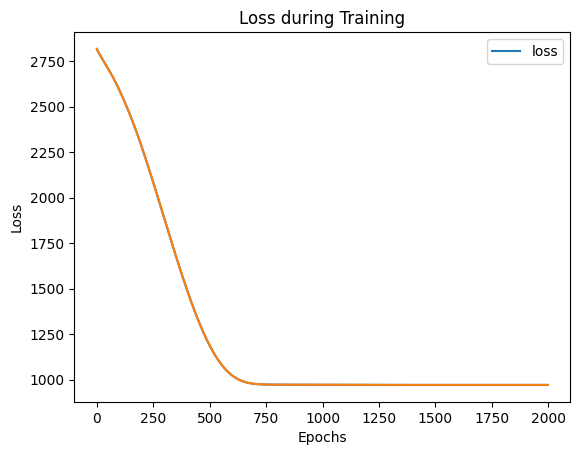

In [39]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.plot(lig.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [40]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = lig (torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 35.610904693603516
